In [3]:
import os
from google.colab import drive
import shutil

# Attempt to unmount first if already mounted, to clear any previous state
if os.path.exists('/content/drive'):
    try:
        drive.flush_and_unmount()
        print("Google Drive unmounted successfully (if previously mounted).")
    except Exception as e:
        print(f"Error during unmount attempt: {e}. Checking directory state.")

    # If unmount didn't clear it or wasn't possible, forcefully remove contents
    if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
        print("Warning: /content/drive still contains files. Forcefully clearing it.")
        try:
            # Use shell command as shutil.rmtree might fail on "mountpoints"
            !rm -rf /content/drive/*
            !rmdir /content/drive 2>/dev/null || true # Remove if empty, ignore error if not
            print("Forcefully cleared /content/drive directory.")
        except Exception as e:
            print(f"Error forcefully clearing /content/drive: {e}")

# Mount Google Drive — this connects Colab to your Drive files
drive.mount('/content/drive', force_remount=True)

# Install packages
!pip install numpy==2.0 pandas==2.2.2 protobuf==5.29.1 packaging==24.2.0 earthengine-api==0.1.384 geemap==0.33.0 scikit-learn==1.6.0 joblib==1.4 requests==2.32.4 -q
!pip install mlflow --user

# Authenticate GEE — click the link it gives you, sign in, paste code back
import ee
ee.Authenticate()
ee.Initialize(project='carbonx-496013')  # paste your actual project ID

# Set working directory to your Drive folder
os.makedirs('/content/drive/MyDrive/CarbonX/data', exist_ok=True)
os.makedirs('/content/drive/MyDrive/CarbonX/artifacts', exist_ok=True)
os.chdir('/content/drive/MyDrive/CarbonX')
print("Setup complete. Current directory:", os.getcwd())

Drive not mounted, so nothing to flush and unmount.
Google Drive unmounted successfully (if previously mounted).
Forcefully cleared /content/drive directory.
Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.6/261.6 kB 9.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.7/319.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 93.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.2/301.2 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

Setup complete. Current directory: /content/drive/MyDrive/CarbonX


In [3]:
import ee
import pandas as pd
import time
import os

# Initialize inside the function so it works both locally and in Colab
def get_sentinel2_features(lat, lon, buffer_meters=2500):
    point = ee.Geometry.Point([lon, lat])
    region = point.buffer(buffer_meters)

    s2_collection = (ee.ImageCollection("COPERNICUS/S2_SR")
                     .filterBounds(region)
                     .filterDate("2023-01-01", "2023-12-31")
                     .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20)))

    # Select only the bands needed before taking the median to ensure homogeneity
    bands_to_select = ['B2', 'B3', 'B4', 'B8', 'B11']
    s2_median = s2_collection.select(bands_to_select).median()

    B2 = s2_median.select("B2")
    B4 = s2_median.select("B4")
    B3 = s2_median.select("B3")
    B8 = s2_median.select("B8")
    B11 = s2_median.select("B11")

    ndvi = s2_median.normalizedDifference(["B8", "B4"]).rename("NDVI")
    evi = s2_median.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {"NIR": B8, "RED": B4, "BLUE": B2}
    ).rename("EVI")
    ndwi = s2_median.normalizedDifference(["B3", "B11"]).rename("NDWI")
    savi = s2_median.expression(
        "((NIR - RED) / (NIR + RED + 0.5)) * 1.5",
        {"NIR": B8, "RED": B4}
    ).rename("SAVI")

    # Spectral heterogeneity — most important feature
    # For NDVI_STD, we need to map the normalizedDifference over the collection first
    # before reducing the collection to get the standard deviation.
    ndvi_std_collection = s2_collection.map(lambda img: img.normalizedDifference(["B8", "B4"]))
    ndvi_std = ndvi_std_collection.reduce(ee.Reducer.stdDev()).rename("NDVI_STD")

    features = ndvi.addBands([evi, ndwi, savi, ndvi_std])

    stats = features.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=10,
        maxPixels=1e9
    )
    return stats.getInfo()


def extract_all_features():
    # Re-adding ee.Initialize() here to ensure it's always set up before GEE calls
    # even if it seems redundant with the global call.
    ee.Initialize(project='carbonx-496013')

    # Construct the full path to the CSV file
    csv_file_path = '/content/drive/MyDrive/CarbonX/data/species_richness.csv'
    richness_df = pd.read_csv(csv_file_path)

    # Resume from checkpoint if extraction was interrupted
    checkpoint_path = '/content/drive/MyDrive/CarbonX/data/features_checkpoint.csv'
    if os.path.exists(checkpoint_path):
        done_df = pd.read_csv(checkpoint_path)
        done_coords = set(zip(done_df["latitude"], done_df["longitude"]))
        print(f"Resuming — {len(done_df)} already done")
    else:
        done_df = pd.DataFrame()
        done_coords = set()

    feature_rows = []
    failed = 0

    for idx, row in richness_df.iterrows():
        coord = (row["latitude"], row["longitude"])
        if coord in done_coords:
            continue

        try:
            print(f"Processing row {idx}: Lat={row['latitude']}, Lon={row['longitude']}")
            features = get_sentinel2_features(row["latitude"], row["longitude"])
            print(f"Features for row {idx}: {features}") # Debug print

            # Skip if GEE returned empty result
            if not features or all(v is None for v in features.values()):
                failed += 1
                print(f"Row {idx} skipped: No features or all None values returned.")
                continue

            features["latitude"] = row["latitude"]
            features["longitude"] = row["longitude"]
            features["species_count"] = row["species_count"]
            feature_rows.append(features)

            # Save checkpoint every 50 rows
            # If Colab disconnects, you won't lose everything
            if len(feature_rows) % 50 == 0:
                checkpoint = pd.concat(
                    [done_df, pd.DataFrame(feature_rows)],
                    ignore_index=True
                )
                checkpoint.to_csv(checkpoint_path, index=False)
                print(f"Checkpoint saved — {len(feature_rows)} new rows, {failed} failed")
                time.sleep(2)

        except Exception as e:
            print(f"Row {idx} failed: {e}")
            failed += 1
            time.sleep(3)
            continue

    # Final save
    final_df = pd.concat(
        [done_df, pd.DataFrame(feature_rows)],
        ignore_index=True
    )
    final_df.to_csv("/content/drive/MyDrive/CarbonX/data/satellite_features.csv", index=False)
    print(f"Done. Total: {len(final_df)} rows. Failed: {failed}")
    return final_df

extract_all_features()

Resuming — 350 already done
Processing row 350: Lat=27.15, Lon=77.5
Features for row 350: {'EVI': 1.016723482586872, 'NDVI': 0.26783944530720505, 'NDVI_STD': 0.1405701387374429, 'NDWI': -0.27951217679431006, 'SAVI': 0.40172303175629037}
Processing row 351: Lat=27.25, Lon=75.55


KeyboardInterrupt: 

In [5]:
import os
# Check checkpoint is saving correctly
checkpoint = '/content/drive/MyDrive/CarbonX/data/features_checkpoint.csv'
if os.path.exists(checkpoint):
    import pandas as pd
    df = pd.read_csv(checkpoint)
    print(f"Checkpoint exists — {len(df)} rows saved so far")
else:
    print("No checkpoint yet — will appear after first 50 rows")

Checkpoint exists — 350 rows saved so far


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features.csv')
print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Missing values:\n{df.isnull().sum()}")
print(df.head())

Total rows: 390
Columns: ['EVI', 'NDVI', 'NDVI_STD', 'NDWI', 'SAVI', 'latitude', 'longitude', 'species_count']
Missing values:
EVI              0
NDVI             0
NDVI_STD         0
NDWI             0
SAVI             0
latitude         0
longitude        0
species_count    0
dtype: int64
        EVI      NDVI  NDVI_STD      NDWI      SAVI  latitude  longitude  \
0  1.478150  0.187992  0.038304 -0.203804  0.281961      8.15      77.30   
1  0.067131 -0.021381  0.010856  0.093163 -0.032066      8.40      76.95   
2  0.500006  0.169920  0.052390 -0.359319  0.254859      8.40      77.60   
3  2.890911  0.335111  0.120755 -0.241120  0.502618      8.45      77.00   
4  1.402720  0.293750  0.096691 -0.253080  0.440587      8.45      77.60   

   species_count  
0            4.0  
1            4.0  
2            3.0  
3            5.0  
4           18.0  


In [8]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

FEATURE_COLS = ["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]

def prepare_data():
    df = pd.read_csv("/content/drive/MyDrive/CarbonX/data/satellite_features.csv")

    print(f"Rows before cleaning: {len(df)}")

    # Drop rows with any missing values
    df = df.dropna(subset=FEATURE_COLS + ["species_count"])
    print(f"Rows after dropping nulls: {len(df)}")

    # Remove outliers from target using 5th-95th percentile
    Q1 = df["species_count"].quantile(0.05)
    Q3 = df["species_count"].quantile(0.95)
    df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]
    print(f"Rows after outlier removal: {len(df)}")

    X = df[FEATURE_COLS]
    y = df["species_count"]

    # Split 80/10/10
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    os.makedirs("artifacts", exist_ok=True)
    joblib.dump(scaler, "/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl")
    print("Scaler saved to artifacts/feature_scaler.pkl")

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test)

if __name__ == "__main__":
    prepare_data()

Rows before cleaning: 390
Rows after dropping nulls: 390
Rows after outlier removal: 370
Train: 296 | Val: 37 | Test: 37
Scaler saved to artifacts/feature_scaler.pkl


In [9]:
import requests
import pandas as pd
import time
import os

def download_gbif_india(limit=5000):
    url = "https://api.gbif.org/v1/occurrence/search"
    all_records = []
    offset = 0

    while len(all_records) < limit:
        params = {
            "country": "IN",
            "basisOfRecord": "HUMAN_OBSERVATION",
            "hasCoordinate": True,
            "hasGeospatialIssue": False,
            "limit": 300,
            "offset": offset
        }
        try:
            response = requests.get(url, params=params, timeout=30)
            response.raise_for_status()
            data = response.json()
            results = data.get("results", [])
            if not results:
                break
            all_records.extend(results)
            offset += 300
            print(f"Downloaded {len(all_records)} records...")
            time.sleep(1)  # Respect GBIF rate limits
        except Exception as e:
            print(f"Error at offset {offset}: {e}")
            time.sleep(5)
            continue

    df = pd.DataFrame(all_records)

    # Keep only columns we need
    cols = ["decimalLatitude", "decimalLongitude", "species"]
    df = df[[c for c in cols if c in df.columns]].dropna()

    os.makedirs("data", exist_ok=True)
    df.to_csv("data/gbif_raw.csv", index=False)
    print(f"Saved {len(df)} records to data/gbif_raw.csv")
    return df

download_gbif_india(limit=5000)

Downloaded 300 records...
Downloaded 600 records...
Downloaded 900 records...
Downloaded 1200 records...
Downloaded 1500 records...
Downloaded 1800 records...
Downloaded 2100 records...
Downloaded 2400 records...
Downloaded 2700 records...
Downloaded 3000 records...
Downloaded 3300 records...
Downloaded 3600 records...
Downloaded 3900 records...
Downloaded 4200 records...
Downloaded 4500 records...
Downloaded 4800 records...
Downloaded 5100 records...
Saved 4991 records to data/gbif_raw.csv


,decimalLatitude,decimalLongitude,species
0,18.366900,73.751200,Tephrodornis pondicerianus
1,11.079803,79.828217,Clamator coromandus
2,12.311931,77.276921,Psilopogon haemacephalus
3,12.782749,80.236628,Egretta garzetta
4,12.509176,79.835800,Gasteracantha geminata
...,...,...,...
5095,10.051687,76.340486,Terpsiphone paradisi
5096,25.413314,81.846528,Borassus flabellifer
5097,18.953960,83.475962,Eryx conicus
5098,9.920630,77.873154,Hottentotta tamulus


In [4]:
import pandas as pd
import os

def aggregate_species_richness(grid_size=0.05):
    df = pd.read_csv("/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv")

    # Round coordinates to grid cells
    df["lat_grid"] = (df["decimalLatitude"] / grid_size).round() * grid_size
    df["lon_grid"] = (df["decimalLongitude"] / grid_size).round() * grid_size

    # Count unique species per grid cell
    richness = df.groupby(
        ["lat_grid", "lon_grid"]
    )["species"].nunique().reset_index()
    richness.columns = ["latitude", "longitude", "species_count"]

    # Remove cells with only 1-2 species — likely incomplete surveys
    richness = richness[richness["species_count"] > 2]

    richness.to_csv("/content/drive/MyDrive/CarbonX/data/species_richness.csv", index=False)
    print(f"Grid cells saved: {len(richness)}")
    print(f"Species count range: {richness['species_count'].min()} - {richness['species_count'].max()}")
    print(f"Saved to data/species_richness.csv")
    return richness

aggregate_species_richness()

Grid cells saved: 843
Species count range: 3 - 152
Saved to data/species_richness.csv


,latitude,longitude,species_count
0,8.10,77.40,3
2,8.15,77.30,5
5,8.30,77.45,4
6,8.35,77.10,4
8,8.40,76.95,5
...,...,...,...
2363,31.40,76.75,12
2374,32.05,76.70,3
2377,32.15,76.30,3
2378,32.20,76.30,6


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

FEATURE_COLS = ["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]

def prepare_data():
    df = pd.read_csv("/content/drive/MyDrive/CarbonX/data/satellite_features.csv")

    print(f"Rows before cleaning: {len(df)}")

    # Drop rows with any missing values
    df = df.dropna(subset=FEATURE_COLS + ["species_count"])
    print(f"Rows after dropping nulls: {len(df)}")

    # Remove outliers from target using 5th-95th percentile
    Q1 = df["species_count"].quantile(0.05)
    Q3 = df["species_count"].quantile(0.95)
    df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]
    print(f"Rows after outlier removal: {len(df)}")

    X = df[FEATURE_COLS]
    y = df["species_count"]

    # Split 80/10/10
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    os.makedirs("artifacts", exist_ok=True)
    joblib.dump(scaler, "/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl")
    print("Scaler saved to artifacts/feature_scaler.pkl")

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test)


prepare_data()

Rows before cleaning: 390
Rows after dropping nulls: 390
Rows after outlier removal: 370
Train: 296 | Val: 37 | Test: 37
Scaler saved to artifacts/feature_scaler.pkl


(array([[-0.80506296,  0.05822224,  0.78961228, -0.80507726, -1.12192823],
        [-0.0991335 ,  0.05822225, -0.04059318, -0.09912425, -0.27504443],
        [-0.75230934,  0.05822224,  1.27709233, -0.75230242, -0.54424049],
        ...,
        [-1.11460598,  0.05822223, -0.41128057, -1.11461309, -1.46322936],
        [-1.06456516,  0.05822223,  0.69826719, -1.06457402, -1.02982268],
        [ 1.74256676,  0.05822227, -0.55886394,  1.74257036, -0.87679747]]),
 array([[-0.17998294,  0.05822224,  0.07728072, -0.17997835, -0.82245229],
        [-1.06910951,  0.05822225,  1.8356046 , -1.06913664, -0.98823959],
        [-0.46648924,  0.05822223,  0.05193768, -0.466488  , -0.93994331],
        [-0.04624838,  0.05822224, -1.12038298, -0.04625794,  0.39325435],
        [ 1.31374969,  0.05822228, -0.23444143,  1.31372301,  0.16429284],
        [ 0.0074379 ,  0.05822225, -0.3578201 ,  0.00743414, -0.35237204],
        [ 1.68398201,  0.05822227, -0.64281851,  1.68398637,  0.83180773],
        [ 

In [23]:
import numpy as np
import mlflow
import mlflow.sklearn
import joblib
import pandas as pd
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = ["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]

def prepare_data():
    df = pd.read_csv("/content/drive/MyDrive/CarbonX/data/satellite_features.csv")

    print(f"Rows before cleaning: {len(df)}")

    # Drop rows with any missing values
    df = df.dropna(subset=FEATURE_COLS + ["species_count"])
    print(f"Rows after dropping nulls: {len(df)}")

    # Remove outliers from target using 5th-95th percentile
    Q1 = df["species_count"].quantile(0.05)
    Q3 = df["species_count"].quantile(0.95)
    df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]
    print(f"Rows after outlier removal: {len(df)}")

    X = df[FEATURE_COLS]
    y = df["species_count"]

    # Split 80/10/10
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )

    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    os.makedirs("artifacts", exist_ok=True)
    joblib.dump(scaler, "/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl")
    print("Scaler saved to artifacts/feature_scaler.pkl")

    return (X_train_scaled, X_val_scaled, X_test_scaled,
            y_train, y_val, y_test)

def train():
    (X_train, X_val, X_test,
     y_train, y_val, y_test) = prepare_data()

    mlflow.set_experiment("biodiversity_model")

    experiments = [
        (100, None, 2,  "baseline"),
        (200, 10,   2,  "shallow"),
        (200, 20,   5,  "medium"),
        (500, 15,   5,  "more_trees"),
        (300, 10,   10, "conservative"),
    ]

    best_r2 = -999
    best_model = None
    best_run_name = None

    for n_est, depth, min_split, name in experiments:
        with mlflow.start_run(run_name=name):
            mlflow.log_param("n_estimators", n_est)
            mlflow.log_param("max_depth", depth)
            mlflow.log_param("min_samples_split", min_split)

            model = RandomForestRegressor(
                n_estimators=n_est,
                max_depth=depth,
                min_samples_split=min_split,
                random_state=42,
                n_jobs=-1
            )
            model.fit(X_train, y_train)

            cv_scores = cross_val_score(
                model, X_train, y_train, cv=5, scoring="r2"
            )
            val_preds = model.predict(X_val)
            val_r2 = r2_score(y_val, val_preds)
            val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
            val_mae = mean_absolute_error(y_val, val_preds)

            mlflow.log_metric("cv_r2_mean", cv_scores.mean())
            mlflow.log_metric("cv_r2_std", cv_scores.std())
            mlflow.log_metric("val_r2", val_r2)
            mlflow.log_metric("val_rmse", val_rmse)
            mlflow.log_metric("val_mae", val_mae)

            importances = dict(zip(FEATURE_COLS, model.feature_importances_))
            for feat, imp in importances.items():
                mlflow.log_metric(f"importance_{feat}", imp)

            mlflow.sklearn.log_model(model, "model")

            print(f"\n{name}: Val R²={val_r2:.3f} | RMSE={val_rmse:.3f}")

            if val_r2 > best_r2:
                best_r2 = val_r2
                best_model = model
                best_run_name = name

    print(f"\nBest: {best_run_name} with R²={best_r2:.3f}")

    # Final test evaluation
    test_preds = best_model.predict(X_test)
    test_r2 = r2_score(y_test, test_preds)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    print(f"\nFinal Test R²: {test_r2:.3f} | RMSE: {test_rmse:.3f}")

    joblib.dump(best_model, "/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl")
    print("Model saved to artifacts/biodiversity_model.pkl")

    return best_model, X_test, y_test

train()

Rows before cleaning: 390
Rows after dropping nulls: 390
Rows after outlier removal: 370
Train: 296 | Val: 37 | Test: 37
Scaler saved to artifacts/feature_scaler.pkl

baseline: Val R²=0.173 | RMSE=4.092

shallow: Val R²=0.166 | RMSE=4.107

medium: Val R²=0.164 | RMSE=4.114

more_trees: Val R²=0.144 | RMSE=4.162

conservative: Val R²=0.156 | RMSE=4.134

Best: baseline with R²=0.173

Final Test R²: -0.197 | RMSE: 5.242
Model saved to artifacts/biodiversity_model.pkl


(RandomForestRegressor(n_jobs=-1, random_state=42),
 array([[ 1.41192663,  0.05822229, -0.09945003,  1.4119372 ,  1.32854158],
        [ 1.34703504,  0.05822224, -1.28289364,  1.34709629, -0.33715393],
        [-0.11356865,  0.05822223, -0.42735945, -0.11354499,  2.17222164],
        [-0.91955262,  0.05822222, -0.89347767, -0.9195305 , -0.22248975],
        [ 0.18846681,  0.05822224, -0.53713765,  0.18849182,  0.65620232],
        [-1.08357317,  0.05822223,  0.54294248, -1.0835789 , -1.39659392],
        [-2.86441572,  0.05822223,  3.67129403, -2.86438813, -1.6073632 ],
        [-0.64286766,  0.05822223,  0.14534479, -0.64285676, -0.13649217],
        [-0.51070964,  0.05822223, -0.48135425, -0.51070543, -0.39174245],
        [-0.00806493,  0.05822224, -0.01493361, -0.00805657,  1.98401889],
        [-2.28819949,  0.05822222,  2.96139113, -2.2882071 , -2.01435547],
        [ 0.03125206,  0.05822224, -0.7511389 ,  0.03126422, -0.34869997],
        [ 0.65929132,  0.05822226, -0.52676761, 

In [24]:
import numpy as np
import pandas as pd
import joblib
import json
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = ["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]

def build_score_converter():
    model = joblib.load("artifacts/biodiversity_model.pkl")
    scaler = joblib.load("artifacts/feature_scaler.pkl")

    df = pd.read_csv("/content/drive/MyDrive/CarbonX/data/satellite_features.csv").dropna(
        subset=FEATURE_COLS
    )
    X_all = scaler.transform(df[FEATURE_COLS])
    all_preds = model.predict(X_all)

    score_scaler = MinMaxScaler(feature_range=(0, 100))
    score_scaler.fit(all_preds.reshape(-1, 1))

    joblib.dump(score_scaler, "/content/drive/MyDrive/CarbonX/artifacts/score_scaler.pkl")

    with open("artifacts/feature_config.json", "w") as f:
        json.dump({"features": FEATURE_COLS}, f)

    print("Score converter saved.")

build_score_converter()

Score converter saved.


In [25]:
import joblib
import pandas as pd
import json

model = joblib.load("/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl")
scaler = joblib.load("/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl")
score_scaler = joblib.load("/content/drive/MyDrive/CarbonX/artifacts/score_scaler.pkl")

with open("artifacts/feature_config.json") as f:
    FEATURE_COLS = json.load(f)["features"]

def predict_biodiversity_score(features: dict) -> float:
    """
    features: dict with keys NDVI, EVI, NDWI, SAVI, NDVI_STD
    returns: float score between 0 and 100

    This is what Person 3 (backend) calls.
    They pass satellite features, get a score back.
    """
    df = pd.DataFrame([features])[FEATURE_COLS]
    scaled = scaler.transform(df)
    raw = model.predict(scaled)
    score = score_scaler.transform(raw.reshape(-1, 1))[0][0]
    return round(float(score), 1)

# Quick test
if __name__ == "__main__":
    test_features = {
        "NDVI": 0.45,
        "EVI": 0.38,
        "NDWI": 0.12,
        "SAVI": 0.41,
        "NDVI_STD": 0.09
    }
    score = predict_biodiversity_score(test_features)
    print(f"Test biodiversity score: {score}/100")

Test biodiversity score: 52.2/100


In [26]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features.csv')
print(df[["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]].describe())
print("\nStandard deviations:")
print(df[["NDVI", "EVI", "NDWI", "SAVI", "NDVI_STD"]].std())

             NDVI           EVI        NDWI        SAVI    NDVI_STD
count  390.000000  3.900000e+02  390.000000  390.000000  390.000000
mean     0.254010 -1.618209e+06   -0.232843    0.380980    0.082343
std      0.106768  3.195709e+07    0.101766    0.160136    0.027888
min     -0.078884 -6.311020e+08   -0.393447   -0.118308    0.010856
25%      0.186707  1.002418e+00   -0.300820    0.280035    0.062379
50%      0.251143  1.264937e+00   -0.254168    0.376681    0.080844
75%      0.317095  1.933564e+00   -0.208496    0.475597    0.098648
max      0.503040  5.597915e+00    0.187969    0.754490    0.186757

Standard deviations:
NDVI        1.067679e-01
EVI         3.195709e+07
NDWI        1.017660e-01
SAVI        1.601357e-01
NDVI_STD    2.788790e-02
dtype: float64


In [27]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features.csv')
print(f"Rows before: {len(df)}")

df = df.drop(columns=["EVI"], errors="ignore")
df = df[(df["NDVI"] >= -1)  & (df["NDVI"] <= 1)]
df = df[(df["NDWI"] >= -1)  & (df["NDWI"] <= 1)]
df = df[(df["SAVI"] >= -2)  & (df["SAVI"] <= 2)]
df = df[(df["NDVI_STD"] >= 0) & (df["NDVI_STD"] <= 1)]

print(f"Rows after: {len(df)}")
print(df[["NDVI","NDWI","SAVI","NDVI_STD"]].std())
df.to_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_clean.csv', index=False)
print("Saved.")

Rows before: 390
Rows after: 390
NDVI        0.106768
NDWI        0.101766
SAVI        0.160136
NDVI_STD    0.027888
dtype: float64
Saved.


In [28]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

FEATURE_COLS = ["NDVI", "NDWI", "SAVI", "NDVI_STD"]

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_clean.csv')
df = df.dropna(subset=FEATURE_COLS + ["species_count"])

Q1 = df["species_count"].quantile(0.05)
Q3 = df["species_count"].quantile(0.95)
df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]

X = df[FEATURE_COLS]
y = df["species_count"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs('/content/drive/MyDrive/CarbonX/artifacts', exist_ok=True)
joblib.dump(scaler, '/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl')
print("Scaler saved.")

Train: 296 | Val: 37 | Test: 37
Scaler saved.


In [29]:
import numpy as np
import mlflow
import mlflow.sklearn
import joblib
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mlflow.set_experiment("biodiversity_v2")

experiments = [
    ("rf_baseline",     "rf", dict(n_estimators=100, max_depth=None, min_samples_split=2)),
    ("rf_shallow",      "rf", dict(n_estimators=200, max_depth=8,    min_samples_split=5)),
    ("rf_conservative", "rf", dict(n_estimators=300, max_depth=6,    min_samples_split=10)),
    ("gb_baseline",     "gb", dict(n_estimators=100, max_depth=3,    learning_rate=0.1)),
    ("gb_slow",         "gb", dict(n_estimators=300, max_depth=3,    learning_rate=0.05)),
]

best_r2    = -999
best_model = None
best_name  = None

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        model = (RandomForestRegressor(**params, random_state=42, n_jobs=-1)
                 if mtype == "rf"
                 else GradientBoostingRegressor(**params, random_state=42))

        model.fit(X_train_scaled, y_train)

        cv  = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
        vp  = model.predict(X_val_scaled)
        vr2 = r2_score(y_val, vp)
        vrmse = np.sqrt(mean_squared_error(y_val, vp))

        mlflow.log_metric("cv_r2_mean", cv.mean())
        mlflow.log_metric("val_r2",     vr2)
        mlflow.log_metric("val_rmse",   vrmse)

        # Feature importances
        imps = dict(zip(FEATURE_COLS, model.feature_importances_))
        for f, v in imps.items():
            mlflow.log_metric(f"imp_{f}", v)
        mlflow.sklearn.log_model(model, "model")

        print(f"{run_name}: Val R²={vr2:.3f} | RMSE={vrmse:.3f} | CV={cv.mean():.3f}±{cv.std():.3f}")
        print(f"  Importances: {imps}")

        if vr2 > best_r2:
            best_r2    = vr2
            best_model = model
            best_name  = run_name

print(f"\nBest: {best_name} → Val R²={best_r2:.3f}")

# Final test score
tp   = best_model.predict(X_test_scaled)
tr2  = r2_score(y_test, tp)
trmse = np.sqrt(mean_squared_error(y_test, tp))
print(f"Test R²={tr2:.3f} | RMSE={trmse:.3f}")

joblib.dump(best_model, '/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl')
print("Model saved.")

2026/05/11 18:33:19 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_v2' does not exist. Creating a new experiment.


rf_baseline: Val R²=0.113 | RMSE=4.238 | CV=-0.190±0.190
  Importances: {'NDVI': 0.1698593574312833, 'NDWI': 0.2993290672403291, 'SAVI': 0.16949443406245687, 'NDVI_STD': 0.3613171412659307}
rf_shallow: Val R²=0.118 | RMSE=4.225 | CV=-0.114±0.131
  Importances: {'NDVI': 0.16554964391526963, 'NDWI': 0.29198219397752884, 'SAVI': 0.1644304206898817, 'NDVI_STD': 0.3780377414173199}
rf_conservative: Val R²=0.143 | RMSE=4.165 | CV=-0.078±0.082
  Importances: {'NDVI': 0.15599276077947197, 'NDWI': 0.2947010584652292, 'SAVI': 0.16301875325341775, 'NDVI_STD': 0.38628742750188105}
gb_baseline: Val R²=-0.006 | RMSE=4.512 | CV=-0.288±0.296
  Importances: {'NDVI': 0.16642994023746632, 'NDWI': 0.317914393313836, 'SAVI': 0.14916842794983015, 'NDVI_STD': 0.36648723849886766}
gb_slow: Val R²=-0.071 | RMSE=4.655 | CV=-0.348±0.307
  Importances: {'NDVI': 0.16073161240433645, 'NDWI': 0.335505414808583, 'SAVI': 0.15178994048394207, 'NDVI_STD': 0.3519730323031384}

Best: rf_conservative → Val R²=0.143
Test R²

In [1]:
import requests
import pandas as pd
import time
import os

def download_gbif_india(limit=15000):
    url = "https://api.gbif.org/v1/occurrence/search"
    all_records = []
    offset = 0

    while len(all_records) < limit:
        params = {
            "country": "IN",
            "basisOfRecord": "HUMAN_OBSERVATION",
            "hasCoordinate": True,
            "hasGeospatialIssue": False,
            "limit": 300,
            "offset": offset
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            data = r.json()
            results = data.get("results", [])
            if not results:
                break
            all_records.extend(results)
            offset += 300
            if len(all_records) % 1500 == 0:
                print(f"Downloaded {len(all_records)} records...")
            time.sleep(0.5)
        except Exception as e:
            print(f"Error at offset {offset}: {e}")
            time.sleep(5)

    df = pd.DataFrame(all_records)
    cols = ["decimalLatitude", "decimalLongitude", "species"]
    df = df[[c for c in cols if c in df.columns]].dropna()
    df.to_csv('/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv', index=False)
    print(f"Saved {len(df)} records.")
    return df

df = download_gbif_india(limit=15000)

Downloaded 1500 records...
Downloaded 3000 records...
Downloaded 4500 records...
Downloaded 6000 records...
Downloaded 7500 records...
Downloaded 9000 records...
Downloaded 10500 records...
Downloaded 12000 records...
Downloaded 13500 records...
Downloaded 15000 records...
Saved 14656 records.


In [5]:
import os

data_path = '/content/drive/MyDrive/CarbonX/data'
if os.path.exists(data_path):
    print(f"Contents of {data_path}:")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"Directory {data_path} does not exist.")

Contents of /content/drive/MyDrive/CarbonX/data:
features_checkpoint.csv
satellite_features.csv
species_richness.csv
satellite_features_clean.csv
gbif_raw_large.csv


In [6]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv')

# Smaller grid = more unique cells = more training rows
# 0.02 degrees ≈ 2km grid instead of 5km
grid_size = 0.02

df["lat_grid"] = (df["decimalLatitude"]  / grid_size).round() * grid_size
df["lon_grid"] = (df["decimalLongitude"] / grid_size).round() * grid_size

richness = df.groupby(
    ["lat_grid", "lon_grid"]
)["species"].nunique().reset_index()
richness.columns = ["latitude", "longitude", "species_count"]

richness = richness[richness["species_count"] > 2]

print(f"Grid cells: {len(richness)}")
print(f"Species range: {richness.species_count.min()} - {richness.species_count.max()}")

richness.to_csv('/content/drive/MyDrive/CarbonX/data/species_richness_large.csv', index=False)

Grid cells: 934
Species range: 3 - 96


In [8]:
import ee
import pandas as pd
import time
import os

ee.Initialize(project='carbonx-496013')

def get_features(lat, lon, buffer_meters=1500):
    point  = ee.Geometry.Point([lon, lat])
    region = point.buffer(buffer_meters)

    # Explicitly select bands before taking the median to ensure homogeneity
    bands_to_select = ['B2', 'B3', 'B4', 'B8', 'B11'] # B2 is often implicitly used in EVI, so including it
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR")
          .filterBounds(region)
          .filterDate("2023-01-01", "2023-12-31")
          .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
          .select(bands_to_select)
          .median())

    B4  = s2.select("B4")
    B8  = s2.select("B8")
    B3  = s2.select("B3")
    B11 = s2.select("B11")
    B2  = s2.select("B2") # Needed for EVI, ensuring it's selected

    ndvi = s2.normalizedDifference(["B8","B4"]).rename("NDVI")
    # Update EVI calculation to use B2 consistently
    evi = s2.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {"NIR": B8, "RED": B4, "BLUE": B2}
    ).rename("EVI")
    ndwi = s2.normalizedDifference(["B3","B11"]).rename("NDWI")
    savi = s2.expression(
        "((NIR-RED)/(NIR+RED+0.5))*1.5",
        {"NIR": B8, "RED": B4}
    ).rename("SAVI")

    # Extra bands — raw reflectance adds signal
    b4_mean  = B4.rename("B4")
    b8_mean  = B8.rename("B8")
    b11_mean = B11.rename("B11")

    # Apply select to NDVI_STD and B8_VAR collections as well
    ndvi_std = (ee.ImageCollection("COPERNICUS/S2_SR")
                .filterBounds(region)
                .filterDate("2023-01-01", "2023-12-31")
                .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
                .select(bands_to_select)
                .map(lambda img: img.normalizedDifference(["B8","B4"]))
                .reduce(ee.Reducer.stdDev())
                .rename("NDVI_STD"))

    # Texture — variance of B8 across region (structural complexity)
    b8_var = (ee.ImageCollection("COPERNICUS/S2_SR")
              .filterBounds(region)
              .filterDate("2023-01-01", "2023-12-31")
              .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
              .select(bands_to_select) # Select bands here too
              .map(lambda img: img.select("B8"))
              .reduce(ee.Reducer.variance())
              .rename("B8_VAR"))

    stack = ndvi.addBands([evi, ndwi, savi, b4_mean, b8_mean, b11_mean, ndvi_std, b8_var])

    stats = stack.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=region,
        scale=10,
        maxPixels=1e9
    )
    return stats.getInfo()

def extract_all(richness_path):
    richness_df  = pd.read_csv(richness_path)
    checkpoint   = '/content/drive/MyDrive/CarbonX/data/features_v2_checkpoint.csv'
    output_path  = '/content/drive/MyDrive/CarbonX/data/satellite_features_v2.csv'

    if os.path.exists(checkpoint):
        done_df     = pd.read_csv(checkpoint)
        done_coords = set(zip(done_df["latitude"], done_df["longitude"]))
        print(f"Resuming from {len(done_df)} rows")
    else:
        done_df     = pd.DataFrame()
        done_coords = set()

    new_rows = []
    failed   = 0

    for idx, row in richness_df.iterrows():
        coord = (row["latitude"], row["longitude"])
        if coord in done_coords:
            continue
        try:
            feats = get_features(row["latitude"], row["longitude"])
            if not feats or all(v is None for v in feats.values()):
                failed += 1
                continue
            feats["latitude"]     = row["latitude"]
            feats["longitude"]    = row["longitude"]
            feats["species_count"]= row["species_count"]
            new_rows.append(feats)

            if len(new_rows) % 50 == 0:
                checkpoint_df = pd.concat(
                    [done_df, pd.DataFrame(new_rows)], ignore_index=True
                )
                checkpoint_df.to_csv(checkpoint, index=False)
                print(f"Checkpoint: {len(checkpoint_df)} rows | failed: {failed}")
                time.sleep(2)

        except Exception as e:
            print(f"Row {idx} failed: {e}")
            failed += 1
            time.sleep(3)

    final = pd.concat([done_df, pd.DataFrame(new_rows)], ignore_index=True)
    final.to_csv(output_path, index=False)
    print(f"Done. {len(final)} rows saved. {failed} failed.")
    return final

extract_all('/content/drive/MyDrive/CarbonX/data/species_richness_large.csv')

Resuming from 50 rows
Checkpoint: 100 rows | failed: 0
Checkpoint: 150 rows | failed: 0
Checkpoint: 200 rows | failed: 0


Checkpoint: 250 rows | failed: 0
Checkpoint: 300 rows | failed: 0
Checkpoint: 350 rows | failed: 0
Checkpoint: 400 rows | failed: 0
Checkpoint: 450 rows | failed: 0
Checkpoint: 500 rows | failed: 0
Checkpoint: 550 rows | failed: 0


Checkpoint: 600 rows | failed: 0
Checkpoint: 650 rows | failed: 0
Checkpoint: 700 rows | failed: 0


Checkpoint: 750 rows | failed: 0
Checkpoint: 800 rows | failed: 0
Checkpoint: 850 rows | failed: 0


Checkpoint: 900 rows | failed: 0
Done. 934 rows saved. 0 failed.


,B11,B4,B8,B8_VAR,NDVI,NDVI_STD,NDWI,SAVI,latitude,longitude,species_count,EVI
0,2188.587144,1724.045621,2260.274923,7.611119e+04,0.096936,0.031451,-0.046890,0.145391,8.14,77.30,4.0,NaN
1,3077.511984,1630.673661,3454.281059,2.161428e+05,0.352690,0.072542,-0.289582,0.528983,8.30,77.44,3.0,NaN
2,2715.112566,1517.562896,3732.701379,1.635899e+06,0.418324,0.116210,-0.248834,0.627426,8.38,77.08,4.0,NaN
3,2737.557222,1662.195754,3229.847479,3.024848e+05,0.298314,0.059346,-0.208318,0.447429,8.40,76.98,4.0,NaN
4,4092.586505,2365.136618,3589.236084,2.361808e+05,0.208851,0.054376,-0.343536,0.313250,8.42,77.60,76.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
929,3118.211792,2054.617908,3503.038492,5.347581e+05,0.260731,0.115411,-0.218923,0.391060,31.32,75.52,6.0,1.134425
930,2833.130885,1527.612799,3394.843978,3.447606e+05,0.379878,0.086153,-0.284284,0.569759,31.42,76.74,12.0,2.174731
931,2601.296913,1597.300238,3294.204676,3.990124e+05,0.344854,0.083761,-0.223406,0.517228,32.14,76.30,3.0,2.360610
932,2547.851876,1591.171083,3109.944341,5.608245e+05,0.322303,0.070126,-0.218528,0.483402,32.20,76.32,6.0,2.711805


In [9]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_v2.csv')
print(f"Rows before: {len(df)}")

df = df.drop(columns=["EVI"], errors="ignore")
df = df[(df["NDVI"] >= -1)  & (df["NDVI"] <= 1)]
df = df[(df["NDWI"] >= -1)  & (df["NDWI"] <= 1)]
df = df[(df["SAVI"] >= -2)  & (df["SAVI"] <= 2)]
df = df[(df["NDVI_STD"] >= 0) & (df["NDVI_STD"] <= 1)]

print(f"Rows after: {len(df)}")
print(df[["NDVI","NDWI","SAVI","NDVI_STD"]].std())
df.to_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_v2_clean.csv', index=False)
print("Saved.")

Rows before: 934
Rows after: 934
NDVI        0.100897
NDWI        0.089341
SAVI        0.151330
NDVI_STD    0.026024
dtype: float64
Saved.


In [10]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import os

FEATURE_COLS = ["NDVI", "NDWI", "SAVI", "NDVI_STD", "B4", "B8", "B11", "B8_VAR"]

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_v2_clean.csv')
df = df.dropna(subset=FEATURE_COLS + ["species_count"])

Q1 = df["species_count"].quantile(0.05)
Q3 = df["species_count"].quantile(0.95)
df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]

X = df[FEATURE_COLS]
y = df["species_count"]

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

os.makedirs('/content/drive/MyDrive/CarbonX/artifacts', exist_ok=True)
joblib.dump(scaler, '/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl')
print("Scaler saved.")

Train: 711 | Val: 89 | Test: 89
Scaler saved.


In [14]:
!pip install mlflow
import os
import sys

# Add the user site-packages to sys.path if not already present
# This is to address ModuleNotFoundError when packages are installed with --user
user_site_packages = os.path.expanduser('~/.local/lib/python' + '.'.join(map(str, sys.version_info[:2])) + '/site-packages')
if user_site_packages not in sys.path:
    sys.path.insert(0, user_site_packages)

import numpy as np
import mlflow
import mlflow.sklearn
import joblib

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mlflow.set_experiment("biodiversity_gbif_2000_species")

experiments = [
    ("rf_baseline", "rf", dict(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
    )),
    ("rf_regularized", "rf", dict(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
    )),
    ("rf_conservative", "rf", dict(
        n_estimators=400,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=3,
    )),
    ("gb_baseline", "gb", dict(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
    )),
    ("gb_regularized", "gb", dict(
        n_estimators=250,
        max_depth=2,
        learning_rate=0.03,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.85,
    )),
]


best_r2 = -999
best_model = None
best_name = None
results = []

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", mtype)
        mlflow.log_params(params)

        if mtype == "rf":
            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = GradientBoostingRegressor(
                **params,
                random_state=42
            )

        model.fit(X_train_scaled, y_train)

        cv = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        )

        vp = model.predict(X_val_scaled)

        vr2 = r2_score(y_val, vp)
        vrmse = np.sqrt(mean_squared_error(y_val, vp))
        vmae = mean_absolute_error(y_val, vp)

        mlflow.log_metric("cv_r2_mean", cv.mean())
        mlflow.log_metric("cv_r2_std", cv.std())
        mlflow.log_metric("val_r2", vr2)
        mlflow.log_metric("val_rmse", vrmse)
        mlflow.log_metric("val_mae", vmae)

        imps = dict(zip(FEATURE_COLS, model.feature_importances_))
        for f, v in imps.items():
            mlflow.log_metric(f"imp_{f}", v)

        mlflow.sklearn.log_model(model, "model")

        results.append({
            "run": run_name,
            "model_type": mtype,
            "cv_r2_mean": cv.mean(),
            "cv_r2_std": cv.std(),
            "val_r2": vr2,
            "val_rmse": vrmse,
            "val_mae": vmae,
        })

        print(
            f"{run_name}: Val R2={vr2:.3f} | "
            f"RMSE={vrmse:.3f} | MAE={vmae:.3f} | "
            f"CV={cv.mean():.3f}+/-{cv.std():.3f}"
        )
        print(f"  Importances: {imps}")

        if vr2 > best_r2:
            best_r2 = vr2
            best_model = model
            best_name = run_name

print(f"\nBest: {best_name} -> Val R2={best_r2:.3f}")

tp = best_model.predict(X_test_scaled)

tr2 = r2_score(y_test, tp)
trmse = np.sqrt(mean_squared_error(y_test, tp))
tmae = mean_absolute_error(y_test, tp)

print(f"Test R2={tr2:.3f} | RMSE={trmse:.3f} | MAE={tmae:.3f}")

os.makedirs("/content/drive/MyDrive/CarbonX/artifacts", exist_ok=True)
joblib.dump(
    best_model,
    "/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl"
)

print("Model saved.")

import pandas as pd
pd.DataFrame(results).sort_values("val_r2", ascending=False)

2026/05/13 17:02:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/13 17:02:22 INFO mlflow.store.db.utils: Updating database tables
2026/05/13 17:02:27 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_gbif_2000_species' does not exist. Creating a new experiment.
2026/05/13 17:02:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:02:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_baseline: Val R2=-0.176 | RMSE=6.166 | MAE=4.661 | CV=-0.120+/-0.057
  Importances: {'NDVI': np.float64(0.07467397252516311), 'NDWI': np.float64(0.14534649010418127), 'SAVI': np.float64(0.07469340999598868), 'NDVI_STD': np.float64(0.16535359322625903), 'B4': np.float64(0.12835940845513882), 'B8': np.float64(0.1293267219800499), 'B11': np.float64(0.12459450221843307), 'B8_VAR': np.float64(0.1576519014947861)}


2026/05/13 17:02:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:02:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_regularized: Val R2=-0.146 | RMSE=6.087 | MAE=4.587 | CV=-0.089+/-0.065
  Importances: {'NDVI': np.float64(0.06787302908389178), 'NDWI': np.float64(0.14066184006414353), 'SAVI': np.float64(0.07076744898595347), 'NDVI_STD': np.float64(0.1763709784966463), 'B4': np.float64(0.1264264767509395), 'B8': np.float64(0.13548997386652384), 'B11': np.float64(0.12501140320961834), 'B8_VAR': np.float64(0.1573988495422833)}


2026/05/13 17:03:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:03:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

2026/05/13 17:03:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:03:17 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_baseline: Val R2=-0.150 | RMSE=6.098 | MAE=4.501 | CV=-0.117+/-0.070
  Importances: {'NDVI': np.float64(0.05403826994708865), 'NDWI': np.float64(0.11100373277121059), 'SAVI': np.float64(0.06345129639563019), 'NDVI_STD': np.float64(0.20475299592190346), 'B4': np.float64(0.12174761780522445), 'B8': np.float64(0.1823211977726365), 'B11': np.float64(0.1289790332142498), 'B8_VAR': np.float64(0.13370585617205635)}


2026/05/13 17:03:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/13 17:03:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_regularized: Val R2=-0.138 | RMSE=6.068 | MAE=4.476 | CV=-0.076+/-0.058
  Importances: {'NDVI': np.float64(0.06273928498854993), 'NDWI': np.float64(0.08364062601050726), 'SAVI': np.float64(0.055812797162361136), 'NDVI_STD': np.float64(0.2463651648061387), 'B4': np.float64(0.12014348485968306), 'B8': np.float64(0.20696688553327416), 'B11': np.float64(0.11114196200178976), 'B8_VAR': np.float64(0.11318979463769602)}

Best: rf_conservative -> Val R2=-0.105
Test R2=-0.145 | RMSE=4.912 | MAE=4.101
Model saved.


,run,model_type,cv_r2_mean,cv_r2_std,val_r2,val_rmse,val_mae
2,rf_conservative,rf,-0.068808,0.055514,-0.104503,5.977231,4.477786
4,gb_regularized,gb,-0.075620,0.058084,-0.138473,6.068452,4.476379
1,rf_regularized,rf,-0.089308,0.065318,-0.145505,6.087165,4.587460
3,gb_baseline,gb,-0.117393,0.070198,-0.149753,6.098439,4.501448
0,rf_baseline,rf,-0.119873,0.057236,-0.175539,6.166447,4.660899


count    889.000000
mean       7.502812
std        5.978588
min        3.000000
25%        3.000000
50%        5.000000
75%        9.000000
max       30.000000
Name: species_count, dtype: float64

Unique species_count values: 28


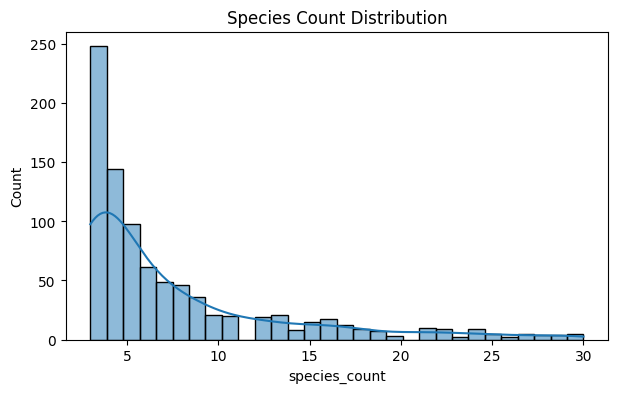

species_count    1.000000
NDWI             0.070271
B4               0.052565
NDVI_STD         0.039014
B11             -0.012942
B8_VAR          -0.022841
B8              -0.065547
NDVI            -0.092139
SAVI            -0.092139
Name: species_count, dtype: float64


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["species_count"].describe())
print("\nUnique species_count values:", df["species_count"].nunique())

plt.figure(figsize=(7,4))
sns.histplot(df["species_count"], bins=30, kde=True)
plt.title("Species Count Distribution")
plt.show()

corr = df[FEATURE_COLS + ["species_count"]].corr(numeric_only=True)["species_count"].sort_values(ascending=False)
print(corr)


In [16]:
import os
import joblib
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

DATA_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v2_clean.csv"
ARTIFACT_DIR = "/content/drive/MyDrive/CarbonX/artifacts"

FEATURE_COLS = [
    "latitude", "longitude",
    "NDVI", "NDWI", "SAVI", "NDVI_STD",
    "B4", "B8", "B11", "B8_VAR"
]

df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=FEATURE_COLS + ["species_count"])

Q1 = df["species_count"].quantile(0.05)
Q3 = df["species_count"].quantile(0.95)
df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]

X = df[FEATURE_COLS]

# Log-transform target to make skewed species counts easier to model.
y = np.log1p(df["species_count"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(scaler, f"{ARTIFACT_DIR}/feature_scaler.pkl")

print("Scaler saved.")


Train: 711 | Val: 89 | Test: 89
Scaler saved.


In [17]:
import mlflow
import mlflow.sklearn

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mlflow.set_experiment("biodiversity_gbif_2000_species_log_target")

experiments = [
    ("rf_baseline", "rf", dict(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
    )),
    ("rf_regularized", "rf", dict(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
    )),
    ("rf_conservative", "rf", dict(
        n_estimators=400,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=3,
    )),
    ("gb_baseline", "gb", dict(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
    )),
    ("gb_regularized", "gb", dict(
        n_estimators=250,
        max_depth=2,
        learning_rate=0.03,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.85,
    )),
]

best_r2 = -999
best_model = None
best_name = None
results = []

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", mtype)
        mlflow.log_params(params)

        if mtype == "rf":
            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = GradientBoostingRegressor(
                **params,
                random_state=42
            )

        model.fit(X_train_scaled, y_train)

        cv = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        )

        val_pred_log = model.predict(X_val_scaled)

        # Convert log predictions back to species-count scale.
        val_pred = np.expm1(val_pred_log)
        y_val_original = np.expm1(y_val)

        vr2 = r2_score(y_val_original, val_pred)
        vrmse = np.sqrt(mean_squared_error(y_val_original, val_pred))
        vmae = mean_absolute_error(y_val_original, val_pred)

        mlflow.log_metric("cv_r2_log_target_mean", cv.mean())
        mlflow.log_metric("cv_r2_log_target_std", cv.std())
        mlflow.log_metric("val_r2_original_scale", vr2)
        mlflow.log_metric("val_rmse_original_scale", vrmse)
        mlflow.log_metric("val_mae_original_scale", vmae)

        imps = dict(zip(FEATURE_COLS, model.feature_importances_))
        for f, v in imps.items():
            mlflow.log_metric(f"imp_{f}", float(v))

        mlflow.sklearn.log_model(model, name="model")

        results.append({
            "run": run_name,
            "model_type": mtype,
            "cv_r2_log_target_mean": cv.mean(),
            "cv_r2_log_target_std": cv.std(),
            "val_r2": vr2,
            "val_rmse": vrmse,
            "val_mae": vmae,
        })

        print(
            f"{run_name}: Val R2={vr2:.3f} | "
            f"RMSE={vrmse:.3f} | MAE={vmae:.3f} | "
            f"CV-log={cv.mean():.3f}+/-{cv.std():.3f}"
        )
        print(f"  Importances: {imps}")

        if vr2 > best_r2:
            best_r2 = vr2
            best_model = model
            best_name = run_name

print(f"\nBest: {best_name} -> Val R2={best_r2:.3f}")


2026/05/13 17:16:09 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_gbif_2000_species_log_target' does not exist. Creating a new experiment.
2026/05/13 17:16:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_baseline: Val R2=-0.043 | RMSE=5.809 | MAE=3.862 | CV-log=-0.063+/-0.090
  Importances: {'latitude': np.float64(0.1098495035814752), 'longitude': np.float64(0.12772299963083122), 'NDVI': np.float64(0.05766837006396753), 'NDWI': np.float64(0.12052854774794955), 'SAVI': np.float64(0.05441598219795589), 'NDVI_STD': np.float64(0.11914060056645187), 'B4': np.float64(0.09682494656447327), 'B8': np.float64(0.09505765006267017), 'B11': np.float64(0.09026923468995603), 'B8_VAR': np.float64(0.12852216489426913)}


2026/05/13 17:16:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_regularized: Val R2=-0.034 | RMSE=5.783 | MAE=3.819 | CV-log=-0.052+/-0.082
  Importances: {'latitude': np.float64(0.11366546400119093), 'longitude': np.float64(0.12654559442126684), 'NDVI': np.float64(0.05299932091080371), 'NDWI': np.float64(0.11867205646554213), 'SAVI': np.float64(0.054720322518042604), 'NDVI_STD': np.float64(0.12225530089880687), 'B4': np.float64(0.09577432464000732), 'B8': np.float64(0.09792394576851896), 'B11': np.float64(0.08904626615712297), 'B8_VAR': np.float64(0.12839740421869775)}


2026/05/13 17:16:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_conservative: Val R2=-0.036 | RMSE=5.788 | MAE=3.767 | CV-log=-0.043+/-0.061
  Importances: {'latitude': np.float64(0.11881759928703191), 'longitude': np.float64(0.12615862614995949), 'NDVI': np.float64(0.050252687310139946), 'NDWI': np.float64(0.12148657599366762), 'SAVI': np.float64(0.05257825577299209), 'NDVI_STD': np.float64(0.11781795990314951), 'B4': np.float64(0.10079134599268215), 'B8': np.float64(0.09569638320041396), 'B11': np.float64(0.08804524213574277), 'B8_VAR': np.float64(0.12835532425422053)}


2026/05/13 17:17:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_baseline: Val R2=-0.090 | RMSE=5.938 | MAE=3.942 | CV-log=-0.061+/-0.083
  Importances: {'latitude': np.float64(0.16129445453770924), 'longitude': np.float64(0.11877982821815487), 'NDVI': np.float64(0.038818344693726206), 'NDWI': np.float64(0.11832519281198568), 'SAVI': np.float64(0.04530058614507557), 'NDVI_STD': np.float64(0.13822233276602738), 'B4': np.float64(0.08870239798031607), 'B8': np.float64(0.1191171300608864), 'B11': np.float64(0.07795481338025552), 'B8_VAR': np.float64(0.09348491940586293)}


2026/05/13 17:17:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_regularized: Val R2=-0.078 | RMSE=5.906 | MAE=3.851 | CV-log=-0.043+/-0.049
  Importances: {'latitude': np.float64(0.18716313447717675), 'longitude': np.float64(0.16159873266649877), 'NDVI': np.float64(0.031848132129926945), 'NDWI': np.float64(0.09266511686959088), 'SAVI': np.float64(0.05173205759179054), 'NDVI_STD': np.float64(0.12289802629793455), 'B4': np.float64(0.07412381532205727), 'B8': np.float64(0.13071538390600107), 'B11': np.float64(0.07864082740525549), 'B8_VAR': np.float64(0.06861477333376771)}

Best: rf_regularized -> Val R2=-0.034


In [18]:
test_pred_log = best_model.predict(X_test_scaled)

test_pred = np.expm1(test_pred_log)
y_test_original = np.expm1(y_test)

tr2 = r2_score(y_test_original, test_pred)
trmse = np.sqrt(mean_squared_error(y_test_original, test_pred))
tmae = mean_absolute_error(y_test_original, test_pred)

print(f"Test R2={tr2:.3f} | RMSE={trmse:.3f} | MAE={tmae:.3f}")

joblib.dump(best_model, f"{ARTIFACT_DIR}/biodiversity_model.pkl")
print("Model saved.")


Test R2=-0.011 | RMSE=4.616 | MAE=3.605
Model saved.


In [19]:
results_df = pd.DataFrame(results).sort_values("val_r2", ascending=False)
results_df


,run,model_type,cv_r2_log_target_mean,cv_r2_log_target_std,val_r2,val_rmse,val_mae
1,rf_regularized,rf,-0.052082,0.082172,-0.034060,5.783481,3.818985
2,rf_conservative,rf,-0.042599,0.060838,-0.035504,5.787518,3.767419
0,rf_baseline,rf,-0.063203,0.089815,-0.043286,5.809224,3.861647
4,gb_regularized,gb,-0.042816,0.048689,-0.078377,5.906113,3.850869
3,gb_baseline,gb,-0.060838,0.083364,-0.090105,5.938143,3.941842


In [22]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)

dummy_pred_log = dummy.predict(X_test_scaled)

dummy_pred = np.expm1(dummy_pred_log)
y_test_original = np.expm1(y_test)

dummy_r2 = r2_score(y_test_original, dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test_original, dummy_pred))
dummy_mae = mean_absolute_error(y_test_original, dummy_pred)

model_pred_log = best_model.predict(X_test_scaled)
model_pred = np.expm1(model_pred_log)

model_r2 = r2_score(y_test_original, model_pred)
model_rmse = np.sqrt(mean_squared_error(y_test_original, model_pred))
model_mae = mean_absolute_error(y_test_original, model_pred)

print("Baseline mean model:")
print(f"R2={dummy_r2:.3f} | RMSE={dummy_rmse:.3f} | MAE={dummy_mae:.3f}")

print("\nBest ML model:")
print(f"R2={model_r2:.3f} | RMSE={model_rmse:.3f} | MAE={model_mae:.3f}")


Baseline mean model:
R2=-0.001 | RMSE=4.593 | MAE=3.411

Best ML model:
R2=-0.011 | RMSE=4.616 | MAE=3.605


In [23]:
joblib.dump(best_model, f"{ARTIFACT_DIR}/biodiversity_model_experimental.pkl")
print("Experimental model saved.")


Experimental model saved.


In [24]:
!pip install earthengine-api -q


In [25]:
import ee
import pandas as pd
import numpy as np
import os

ee.Authenticate()
ee.Initialize()


In [26]:
DATA_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v2_clean.csv"
OUT_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v3_environmental.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.columns)


(934, 11)
Index(['B11', 'B4', 'B8', 'B8_VAR', 'NDVI', 'NDVI_STD', 'NDWI', 'SAVI',
       'latitude', 'longitude', 'species_count'],
      dtype='object')


In [27]:
# Keep only rows with coordinates.
df = df.dropna(subset=["latitude", "longitude"]).copy()
df = df.reset_index(drop=True)
df["row_id"] = df.index

features = []

for _, row in df.iterrows():
    point = ee.Geometry.Point([float(row["longitude"]), float(row["latitude"])])
    feat = ee.Feature(point, {"row_id": int(row["row_id"])})
    features.append(feat)

points_fc = ee.FeatureCollection(features)

# Environmental datasets.
elevation = ee.Image("USGS/SRTMGL1_003").select("elevation").rename("elevation")
slope = ee.Terrain.slope(elevation).rename("slope")

bio = ee.Image("WORLDCLIM/V1/BIO")
temp_mean = bio.select("bio01").multiply(0.1).rename("temp_mean_c")
precip_annual = bio.select("bio12").rename("precip_annual_mm")

landcover = (
    ee.ImageCollection("ESA/WorldCover/v200")
    .first()
    .select("Map")
    .rename("landcover")
)

human_mod = (
    ee.ImageCollection("CSP/HM/GlobalHumanModification")
    .first()
    .select("gHM")
    .rename("human_modification")
)

env_image = elevation.addBands([
    slope,
    temp_mean,
    precip_annual,
    landcover,
    human_mod
])

sampled = env_image.reduceRegions(
    collection=points_fc,
    reducer=ee.Reducer.first(),
    scale=1000
)

env_data = sampled.getInfo()["features"]

rows = []
for feat in env_data:
    props = feat["properties"]
    rows.append(props)

env_df = pd.DataFrame(rows)

df_v3 = df.merge(env_df, on="row_id", how="left")
df_v3 = df_v3.drop(columns=["row_id"])

df_v3.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print(df_v3.shape)
print(df_v3[[
    "elevation",
    "slope",
    "temp_mean_c",
    "precip_annual_mm",
    "landcover",
    "human_modification"
]].isna().sum())


Saved: /content/drive/MyDrive/CarbonX/data/satellite_features_v3_environmental.csv
(934, 17)
elevation              0
slope                  0
temp_mean_c           33
precip_annual_mm      33
landcover              0
human_modification    23
dtype: int64


In [29]:
import os
import joblib
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

DATA_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v3_environmental.csv"
ARTIFACT_DIR = "/content/drive/MyDrive/CarbonX/artifacts"

FEATURE_COLS = [
    "latitude", "longitude",
    "NDVI", "NDWI", "SAVI", "NDVI_STD",
    "B4", "B8", "B11", "B8_VAR",
    "elevation", "slope",
    "temp_mean_c", "precip_annual_mm",
    "landcover", "human_modification"
]

df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=FEATURE_COLS + ["species_count"])

Q1 = df["species_count"].quantile(0.05)
Q3 = df["species_count"].quantile(0.95)
df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]

print("Rows after cleaning:", len(df))
print(df["species_count"].describe())

X = df[FEATURE_COLS]
y = np.log1p(df["species_count"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(scaler, f"{ARTIFACT_DIR}/feature_scaler_v3.pkl")

print("Scaler saved.")


Rows after cleaning: 852
count    852.000000
mean       7.480047
std        5.929339
min        3.000000
25%        3.000000
50%        5.000000
75%        9.000000
max       30.000000
Name: species_count, dtype: float64
Train: 681 | Val: 85 | Test: 86
Scaler saved.


In [30]:
mlflow.set_experiment("biodiversity_v3_environmental_features")

experiments = [
    ("rf_regularized", "rf", dict(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
    )),
    ("rf_conservative", "rf", dict(
        n_estimators=400,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=3,
    )),
    ("gb_regularized", "gb", dict(
        n_estimators=250,
        max_depth=2,
        learning_rate=0.03,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.85,
    )),
    ("gb_baseline", "gb", dict(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
    )),
]

best_r2 = -999
best_model = None
best_name = None
results = []

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", mtype)
        mlflow.log_params(params)

        if mtype == "rf":
            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = GradientBoostingRegressor(
                **params,
                random_state=42
            )

        model.fit(X_train_scaled, y_train)

        cv = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        )

        val_pred = np.expm1(model.predict(X_val_scaled))
        y_val_original = np.expm1(y_val)

        vr2 = r2_score(y_val_original, val_pred)
        vrmse = np.sqrt(mean_squared_error(y_val_original, val_pred))
        vmae = mean_absolute_error(y_val_original, val_pred)

        imps = dict(zip(FEATURE_COLS, model.feature_importances_))

        mlflow.log_metric("cv_r2_log_mean", cv.mean())
        mlflow.log_metric("cv_r2_log_std", cv.std())
        mlflow.log_metric("val_r2", vr2)
        mlflow.log_metric("val_rmse", vrmse)
        mlflow.log_metric("val_mae", vmae)

        for f, v in imps.items():
            mlflow.log_metric(f"imp_{f}", float(v))

        mlflow.sklearn.log_model(model, name="model")

        results.append({
            "run": run_name,
            "model_type": mtype,
            "cv_r2_log_mean": cv.mean(),
            "cv_r2_log_std": cv.std(),
            "val_r2": vr2,
            "val_rmse": vrmse,
            "val_mae": vmae,
        })

        print(
            f"{run_name}: Val R2={vr2:.3f} | "
            f"RMSE={vrmse:.3f} | MAE={vmae:.3f}"
        )

        if vr2 > best_r2:
            best_r2 = vr2
            best_model = model
            best_name = run_name

print(f"\nBest: {best_name} -> Val R2={best_r2:.3f}")

results_df = pd.DataFrame(results).sort_values("val_r2", ascending=False)
results_df


2026/05/13 17:29:39 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_v3_environmental_features' does not exist. Creating a new experiment.
2026/05/13 17:29:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_regularized: Val R2=-0.086 | RMSE=5.650 | MAE=3.993


2026/05/13 17:30:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_conservative: Val R2=-0.072 | RMSE=5.615 | MAE=3.957


2026/05/13 17:30:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_regularized: Val R2=-0.120 | RMSE=5.737 | MAE=4.043


2026/05/13 17:30:38 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_baseline: Val R2=-0.134 | RMSE=5.773 | MAE=4.088

Best: rf_conservative -> Val R2=-0.072


,run,model_type,cv_r2_log_mean,cv_r2_log_std,val_r2,val_rmse,val_mae
1,rf_conservative,rf,-0.084051,0.060125,-0.072276,5.614586,3.956609
0,rf_regularized,rf,-0.097112,0.061404,-0.085854,5.650023,3.993153
2,gb_regularized,gb,-0.086593,0.066235,-0.119546,5.737007,4.043144
3,gb_baseline,gb,-0.125973,0.067498,-0.133659,5.773054,4.087888


In [33]:
import os
import pandas as pd

GBIF_PATH = "/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv"
OUT_PATH = "/content/drive/MyDrive/CarbonX/data/species_richness_v2.csv"

grid_size = 0.05

df = pd.read_csv(GBIF_PATH)

df = df.dropna(subset=[
    "decimalLatitude",
    "decimalLongitude",
    "species"
])

df["lat_grid"] = (df["decimalLatitude"] / grid_size).round() * grid_size
df["lon_grid"] = (df["decimalLongitude"] / grid_size).round() * grid_size

richness = (
    df.groupby(["lat_grid", "lon_grid"])
    .agg(
        species_count=("species", "nunique"),
        observation_count=("species", "size"),
    )
    .reset_index()
    .rename(columns={
        "lat_grid": "latitude",
        "lon_grid": "longitude",
    })
)

richness["richness_rate"] = (
    richness["species_count"] / richness["observation_count"]
)

richness = richness[
    (richness["species_count"] > 2) &
    (richness["observation_count"] >= 5)
].copy()

os.makedirs("/content/drive/MyDrive/CarbonX/data", exist_ok=True)
richness.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Grid cells:", len(richness))
print(richness.head())
print(richness.describe())

Saved: /content/drive/MyDrive/CarbonX/data/species_richness_v2.csv
Grid cells: 572
    latitude  longitude  species_count  observation_count  richness_rate
2       8.15      77.30              5                  5       1.000000
8       8.40      76.95              5                  6       0.833333
11      8.40      77.60             14                 15       0.933333
13      8.45      77.00             17                 17       1.000000
16      8.45      77.60             69                 93       0.741935
         latitude   longitude  species_count  observation_count  richness_rate
count  572.000000  572.000000     572.000000         572.000000     572.000000
mean    17.609790   77.830594      14.760490          20.639860       0.847214
std      6.396793    4.101505      14.906021          32.177371       0.163516
min      8.150000   68.950000       3.000000           5.000000       0.223124
25%     12.200000   75.687500       6.000000           6.000000       0.750000
50%  

In [35]:
import os
import pandas as pd

GBIF_PATH = "/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv"
OUT_PATH = "/content/drive/MyDrive/CarbonX/data/species_richness_v2.csv"

grid_size = 0.05

df = pd.read_csv(GBIF_PATH)

df = df.dropna(subset=[
    "decimalLatitude",
    "decimalLongitude",
    "species"
])

df["lat_grid"] = (df["decimalLatitude"] / grid_size).round() * grid_size
df["lon_grid"] = (df["decimalLongitude"] / grid_size).round() * grid_size

richness = (
    df.groupby(["lat_grid", "lon_grid"])
    .agg(
        species_count=("species", "nunique"),
        observation_count=("species", "size"),
    )
    .reset_index()
    .rename(columns={
        "lat_grid": "latitude",
        "lon_grid": "longitude",
    })
)

richness["richness_rate"] = (
    richness["species_count"] / richness["observation_count"]
)

richness = richness[
    (richness["species_count"] > 2) &
    (richness["observation_count"] >= 5)
].copy()

os.makedirs("/content/drive/MyDrive/CarbonX/data", exist_ok=True)
richness.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Grid cells:", len(richness))
print(richness.head())
print(richness.describe())


Saved: /content/drive/MyDrive/CarbonX/data/species_richness_v2.csv
Grid cells: 572
    latitude  longitude  species_count  observation_count  richness_rate
2       8.15      77.30              5                  5       1.000000
8       8.40      76.95              5                  6       0.833333
11      8.40      77.60             14                 15       0.933333
13      8.45      77.00             17                 17       1.000000
16      8.45      77.60             69                 93       0.741935
         latitude   longitude  species_count  observation_count  richness_rate
count  572.000000  572.000000     572.000000         572.000000     572.000000
mean    17.609790   77.830594      14.760490          20.639860       0.847214
std      6.396793    4.101505      14.906021          32.177371       0.163516
min      8.150000   68.950000       3.000000           5.000000       0.223124
25%     12.200000   75.687500       6.000000           6.000000       0.750000
50%  

In [36]:
import pandas as pd
import numpy as np

FEATURE_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v2_clean.csv"
RICHNESS_PATH = "/content/drive/MyDrive/CarbonX/data/species_richness_v2.csv"
OUT_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v4_effort_corrected.csv"

features_df = pd.read_csv(FEATURE_PATH)
richness_df = pd.read_csv(RICHNESS_PATH)

features_df["latitude"] = features_df["latitude"].round(6)
features_df["longitude"] = features_df["longitude"].round(6)
richness_df["latitude"] = richness_df["latitude"].round(6)
richness_df["longitude"] = richness_df["longitude"].round(6)

richness_keep = richness_df[[
    "latitude",
    "longitude",
    "species_count",
    "observation_count",
    "richness_rate"
]]

features_no_target = features_df.drop(
    columns=[
        c for c in ["species_count", "observation_count", "richness_rate"]
        if c in features_df.columns
    ]
)

df_v4 = features_no_target.merge(
    richness_keep,
    on=["latitude", "longitude"],
    how="inner"
)

df_v4.to_csv(OUT_PATH, index=False)

print("Saved:", OUT_PATH)
print("Rows:", len(df_v4))
print(df_v4.head())
print(df_v4[["species_count", "observation_count", "richness_rate"]].describe())


Saved: /content/drive/MyDrive/CarbonX/data/satellite_features_v4_effort_corrected.csv
Rows: 35
           B11           B4           B8        B8_VAR      NDVI  NDVI_STD  \
0  2177.140507  1538.954183  2974.626786  1.283179e+06  0.282394  0.113069   
1  3285.815530  1522.142134  3870.911703  2.905331e+05  0.428694  0.059681   
2  2849.173557  1585.681095  3824.972712  1.992127e+06  0.412228  0.126211   
3  2980.461499  1645.900950  3584.918775  1.708484e+06  0.367831  0.118194   
4  2508.661351  1543.383656  3169.226521  1.359705e+06  0.329785  0.095083   

       NDWI      SAVI  latitude  longitude  species_count  observation_count  \
0 -0.080239  0.423549       9.8       76.3             23                 36   
1 -0.335392  0.642982      10.1       76.8              6                  6   
2 -0.246627  0.618285      10.2       76.3             15                 16   
3 -0.267200  0.551694      10.3       76.2              6                  6   
4 -0.208160  0.494628      10.4     

In [37]:
import os
import joblib
import numpy as np
import pandas as pd
import mlflow
import mlflow.sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

DATA_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v4_effort_corrected.csv"
ARTIFACT_DIR = "/content/drive/MyDrive/CarbonX/artifacts"

FEATURE_COLS = [
    "latitude", "longitude",
    "observation_count",
    "NDVI", "NDWI", "SAVI", "NDVI_STD",
    "B4", "B8", "B11", "B8_VAR"
]

df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=FEATURE_COLS + ["species_count"])

Q1 = df["species_count"].quantile(0.05)
Q3 = df["species_count"].quantile(0.95)
df = df[(df["species_count"] >= Q1) & (df["species_count"] <= Q3)]

print("Rows after cleaning:", len(df))
print(df[["species_count", "observation_count", "richness_rate"]].describe())

X = df[FEATURE_COLS]
y = np.log1p(df["species_count"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

os.makedirs(ARTIFACT_DIR, exist_ok=True)
joblib.dump(scaler, f"{ARTIFACT_DIR}/feature_scaler_v4.pkl")

print("Scaler saved.")


Rows after cleaning: 32
       species_count  observation_count  richness_rate
count      32.000000          32.000000      32.000000
mean       18.062500          24.812500       0.806177
std        12.863897          20.204499       0.162170
min         6.000000           6.000000       0.534884
25%         8.500000           9.500000       0.646825
50%        15.000000          16.500000       0.825117
75%        23.000000          36.250000       0.953125
max        58.000000          86.000000       1.000000
Train: 25 | Val: 3 | Test: 4
Scaler saved.


In [38]:
mlflow.set_experiment("biodiversity_v4_observation_count_feature")

experiments = [
    ("rf_regularized", "rf", dict(
        n_estimators=300,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
    )),
    ("rf_conservative", "rf", dict(
        n_estimators=400,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=3,
    )),
    ("gb_regularized", "gb", dict(
        n_estimators=250,
        max_depth=2,
        learning_rate=0.03,
        min_samples_split=5,
        min_samples_leaf=3,
        subsample=0.85,
    )),
    ("gb_baseline", "gb", dict(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
    )),
]

best_r2 = -999
best_model = None
best_name = None
results = []

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_param("model_type", mtype)
        mlflow.log_params(params)

        if mtype == "rf":
            model = RandomForestRegressor(
                **params,
                random_state=42,
                n_jobs=-1
            )
        else:
            model = GradientBoostingRegressor(
                **params,
                random_state=42
            )

        model.fit(X_train_scaled, y_train)

        cv = cross_val_score(
            model,
            X_train_scaled,
            y_train,
            cv=5,
            scoring="r2"
        )

        val_pred = np.expm1(model.predict(X_val_scaled))
        y_val_original = np.expm1(y_val)

        vr2 = r2_score(y_val_original, val_pred)
        vrmse = np.sqrt(mean_squared_error(y_val_original, val_pred))
        vmae = mean_absolute_error(y_val_original, val_pred)

        imps = dict(zip(FEATURE_COLS, model.feature_importances_))

        mlflow.log_metric("cv_r2_log_mean", cv.mean())
        mlflow.log_metric("cv_r2_log_std", cv.std())
        mlflow.log_metric("val_r2", vr2)
        mlflow.log_metric("val_rmse", vrmse)
        mlflow.log_metric("val_mae", vmae)

        for f, v in imps.items():
            mlflow.log_metric(f"imp_{f}", float(v))

        mlflow.sklearn.log_model(model, name="model")

        results.append({
            "run": run_name,
            "model_type": mtype,
            "cv_r2_log_mean": cv.mean(),
            "cv_r2_log_std": cv.std(),
            "val_r2": vr2,
            "val_rmse": vrmse,
            "val_mae": vmae,
        })

        print(
            f"{run_name}: Val R2={vr2:.3f} | "
            f"RMSE={vrmse:.3f} | MAE={vmae:.3f}"
        )
        print(f"  Importances: {imps}")

        if vr2 > best_r2:
            best_r2 = vr2
            best_model = model
            best_name = run_name

print(f"\nBest: {best_name} -> Val R2={best_r2:.3f}")

results_df = pd.DataFrame(results).sort_values("val_r2", ascending=False)
results_df


2026/05/13 17:42:27 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_v4_observation_count_feature' does not exist. Creating a new experiment.
2026/05/13 17:42:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_regularized: Val R2=-0.560 | RMSE=2.123 | MAE=1.911
  Importances: {'latitude': np.float64(0.006955971341129913), 'longitude': np.float64(0.0067886786432331874), 'observation_count': np.float64(0.9083612286590932), 'NDVI': np.float64(0.011511870942337585), 'NDWI': np.float64(0.005799777277037733), 'SAVI': np.float64(0.012422682523840208), 'NDVI_STD': np.float64(0.026743615651715277), 'B4': np.float64(0.006676776800878616), 'B8': np.float64(0.0054462273263462), 'B11': np.float64(0.005612115890242159), 'B8_VAR': np.float64(0.0036810549441459316)}


2026/05/13 17:42:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_conservative: Val R2=-0.353 | RMSE=1.977 | MAE=1.868
  Importances: {'latitude': np.float64(0.0011528306606596811), 'longitude': np.float64(0.0025540545754892), 'observation_count': np.float64(0.9539097010471806), 'NDVI': np.float64(0.010859921096235651), 'NDWI': np.float64(0.0), 'SAVI': np.float64(0.009762878786601226), 'NDVI_STD': np.float64(0.012815090138829335), 'B4': np.float64(0.002308840208215113), 'B8': np.float64(0.003382557037676898), 'B11': np.float64(0.003254126449112112), 'B8_VAR': np.float64(0.0)}


2026/05/13 17:42:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_regularized: Val R2=0.167 | RMSE=1.551 | MAE=1.162
  Importances: {'latitude': np.float64(0.011451633086898089), 'longitude': np.float64(0.008402223404142829), 'observation_count': np.float64(0.9480116158401505), 'NDVI': np.float64(0.0016507960031182454), 'NDWI': np.float64(0.008188020537149971), 'SAVI': np.float64(0.003798539814608011), 'NDVI_STD': np.float64(0.006767922988229597), 'B4': np.float64(0.0006460001851940315), 'B8': np.float64(0.0031329649692299006), 'B11': np.float64(0.00633851276069689), 'B8_VAR': np.float64(0.001611770410582031)}


2026/05/13 17:42:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_baseline: Val R2=-0.364 | RMSE=1.985 | MAE=1.200
  Importances: {'latitude': np.float64(0.011832648840110668), 'longitude': np.float64(0.006206007832978223), 'observation_count': np.float64(0.9545990080134393), 'NDVI': np.float64(0.00156396825693947), 'NDWI': np.float64(0.0026221359763026995), 'SAVI': np.float64(0.00401629824639721), 'NDVI_STD': np.float64(0.01012444767226272), 'B4': np.float64(0.003751812837840709), 'B8': np.float64(0.001413076887601735), 'B11': np.float64(0.0022166689317316044), 'B8_VAR': np.float64(0.001653926504395685)}

Best: gb_regularized -> Val R2=0.167


,run,model_type,cv_r2_log_mean,cv_r2_log_std,val_r2,val_rmse,val_mae
2,gb_regularized,gb,0.767036,0.152228,0.167262,1.551028,1.161668
1,rf_conservative,rf,0.591084,0.125080,-0.353014,1.977045,1.868204
3,gb_baseline,gb,0.821330,0.118964,-0.364121,1.985143,1.199684
0,rf_regularized,rf,0.781821,0.122944,-0.559604,2.122621,1.911210


In [39]:
y_test_original = np.expm1(y_test)

dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train_scaled, y_train)

dummy_pred = np.expm1(dummy.predict(X_test_scaled))
model_pred = np.expm1(best_model.predict(X_test_scaled))

dummy_r2 = r2_score(y_test_original, dummy_pred)
dummy_rmse = np.sqrt(mean_squared_error(y_test_original, dummy_pred))
dummy_mae = mean_absolute_error(y_test_original, dummy_pred)

model_r2 = r2_score(y_test_original, model_pred)
model_rmse = np.sqrt(mean_squared_error(y_test_original, model_pred))
model_mae = mean_absolute_error(y_test_original, model_pred)

print("Baseline mean model:")
print(f"R2={dummy_r2:.3f} | RMSE={dummy_rmse:.3f} | MAE={dummy_mae:.3f}")

print("\nBest ML model:")
print(f"R2={model_r2:.3f} | RMSE={model_rmse:.3f} | MAE={model_mae:.3f}")


Baseline mean model:
R2=-3.130 | RMSE=8.001 | MAE=6.965

Best ML model:
R2=0.871 | RMSE=1.416 | MAE=1.168


In [40]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df


,feature,importance
2,observation_count,0.948012
0,latitude,0.011452
1,longitude,0.008402
4,NDWI,0.008188
6,NDVI_STD,0.006768
9,B11,0.006339
5,SAVI,0.003799
8,B8,0.003133
3,NDVI,0.001651
10,B8_VAR,0.001612


In [2]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = "/content/drive/MyDrive/CarbonX/data/satellite_features_v4_effort_corrected.csv"
ARTIFACT_DIR = "/content/drive/MyDrive/CarbonX/artifacts"
REPORT_DIR = "/content/drive/MyDrive/CarbonX/reports"

os.makedirs(ARTIFACT_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

TARGET_COL = "species_count"

# Do NOT include observation_count as a feature for app prediction.
# It is used only as sample_weight because it represents GBIF confidence/sampling effort.
FEATURE_COLS = [
    "latitude", "longitude",
    "NDVI", "NDWI", "SAVI", "NDVI_STD",
    "B4", "B8", "B11", "B8_VAR"
]

df = pd.read_csv(DATA_PATH)

df = df.dropna(subset=FEATURE_COLS + [TARGET_COL]).copy()

# Keep moderate outlier filtering.
q_low = df[TARGET_COL].quantile(0.05)
q_high = df[TARGET_COL].quantile(0.95)
df = df[(df[TARGET_COL] >= q_low) & (df[TARGET_COL] <= q_high)].copy()

# Sample weights: more GBIF observations = more reliable label,
# but cap the effect so highly observed locations do not dominate fully.
if "observation_count" in df.columns:
    sample_weight = np.sqrt(df["observation_count"].clip(lower=1, upper=df["observation_count"].quantile(0.95)))
else:
    sample_weight = None

X = df[FEATURE_COLS]
y = np.log1p(df[TARGET_COL])

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X,
    y,
    sample_weight,
    test_size=0.2,
    random_state=42
)

numeric_features = FEATURE_COLS

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        )
    ]
)

rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", rf)
])

param_grid = {
    "regressor__n_estimators": [300, 500, 800],
    "regressor__max_depth": [8, 12, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", 0.7, 1.0],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(
    X_train,
    y_train,
    regressor__sample_weight=w_train
)

best_model = search.best_estimator_

pred_log = best_model.predict(X_test)
pred = np.expm1(pred_log)
y_test_original = np.expm1(y_test)

r2 = r2_score(y_test_original, pred)
rmse = np.sqrt(mean_squared_error(y_test_original, pred))
mae = mean_absolute_error(y_test_original, pred)

print("Best parameters:")
print(search.best_params_)

print("\nTest metrics:")
print(f"R2   = {r2:.3f}")
print(f"RMSE = {rmse:.3f}")
print(f"MAE  = {mae:.3f}")

rf_model = best_model.named_steps["regressor"]

importances = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop feature importances:")
print(importances)

plt.figure(figsize=(8, 5))
plt.barh(importances["feature"], importances["importance"])
plt.gca().invert_yaxis()
plt.title("Biodiversity Model Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/biodiversity_feature_importance.png", dpi=200)
plt.show()

# Per-tree uncertainty.
X_test_processed = best_model.named_steps["preprocessor"].transform(X_test)

tree_preds_log = np.array([
    tree.predict(X_test_processed)
    for tree in rf_model.estimators_
])

tree_preds = np.expm1(tree_preds_log)

pred_mean = tree_preds.mean(axis=0)
pred_std = tree_preds.std(axis=0)
pred_lower = np.percentile(tree_preds, 5, axis=0)
pred_upper = np.percentile(tree_preds, 95, axis=0)

uncertainty_df = pd.DataFrame({
    "actual_species_count": y_test_original.values,
    "predicted_species_count": pred_mean,
    "prediction_std": pred_std,
    "prediction_p05": pred_lower,
    "prediction_p95": pred_upper,
})

display(uncertainty_df.head())

metrics = {
    "target": TARGET_COL,
    "rows_used": int(len(df)),
    "features": FEATURE_COLS,
    "best_params": search.best_params_,
    "test_r2": float(r2),
    "test_rmse": float(rmse),
    "test_mae": float(mae),
    "cv_best_score_neg_rmse": float(search.best_score_),
}

with open(f"{REPORT_DIR}/biodiversity_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

joblib.dump(best_model, f"{ARTIFACT_DIR}/biodiversity_rf_model.joblib")
uncertainty_df.to_csv(f"{REPORT_DIR}/biodiversity_uncertainty_predictions.csv", index=False)

print("\nSaved:")
print(f"{ARTIFACT_DIR}/biodiversity_rf_model.joblib")
print(f"{REPORT_DIR}/biodiversity_metrics.json")
print(f"{REPORT_DIR}/biodiversity_feature_importance.png")
print(f"{REPORT_DIR}/biodiversity_uncertainty_predictions.csv")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/CarbonX/data/satellite_features_v4_effort_corrected.csv'

In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/gbif_raw_large.csv')

grid_size = 0.02
df["lat_grid"] = (df["decimalLatitude"]  / grid_size).round() * grid_size
df["lon_grid"] = (df["decimalLongitude"] / grid_size).round() * grid_size

richness = df.groupby(["lat_grid","lon_grid"]).agg(
    species_count    =("species", "nunique"),
    observation_count=("species", "count")
).reset_index()
richness.columns = ["latitude","longitude","species_count","observation_count"]
richness = richness[richness["species_count"] > 2]

print(f"Grid cells: {len(richness)}")
print(richness[["species_count","observation_count"]].describe())
richness.to_csv('/content/drive/MyDrive/CarbonX/data/species_richness_weighted.csv', index=False)

Grid cells: 934
       species_count  observation_count
count     934.000000         934.000000
mean        9.374732          12.526767
std        10.580516          21.102232
min         3.000000           3.000000
25%         3.000000           4.000000
50%         5.000000           6.000000
75%        10.000000          12.000000
max        96.000000         406.000000


In [3]:
import pandas as pd

features = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_v2.csv')
richness  = pd.read_csv('/content/drive/MyDrive/CarbonX/data/species_richness_weighted.csv')

df = features.merge(richness[["latitude","longitude","observation_count"]],
                    on=["latitude","longitude"], how="left")

df["observation_count"] = df["observation_count"].fillna(1)
print(f"Rows: {len(df)}")
print(df["observation_count"].describe())
df.to_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_weighted.csv', index=False)

Rows: 934
count    934.000000
mean      12.526767
std       21.102232
min        3.000000
25%        4.000000
50%        6.000000
75%       12.000000
max      406.000000
Name: observation_count, dtype: float64


In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import joblib

FEATURE_COLS = ["NDVI","NDWI","SAVI","NDVI_STD","B4","B8","B11","B8_VAR"]

df = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_weighted.csv')
df = df.dropna(subset=FEATURE_COLS + ["observation_count"])

# Filter to farmland range only
df = df[(df["NDVI"] >= 0.15) & (df["NDVI"] <= 0.65)]
df = df[df["NDVI_STD"] > 0.03]
print(f"Rows after farmland filter: {len(df)}")

# Build satellite-derived biodiversity index (target)
def norm(s): return (s - s.min()) / (s.max() - s.min() + 1e-8)

df["bio_index"] = (
    norm(df["NDVI_STD"]) * 0.35 +
    norm(df["B8_VAR"])   * 0.25 +
    norm(df["NDVI"])     * 0.20 +
    norm(df["NDWI"])     * 0.20
)

# Normalise observation_count to use as sample weight (1 to 10 range)
obs = df["observation_count"].values
weights = 1 + 9 * (obs - obs.min()) / (obs.max() - obs.min() + 1e-8)

X = df[FEATURE_COLS]
y = df["bio_index"]

X_train, X_temp, y_train, y_temp, w_train, w_temp = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)
X_val, X_test, y_val, y_test, w_val, w_test = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.5, random_state=42
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

joblib.dump(scaler, '/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl')
print("Scaler saved.")

Rows after farmland filter: 853
Train: 682 | Val: 85 | Test: 86
Scaler saved.


In [6]:
import numpy as np
import mlflow
import mlflow.sklearn
import joblib
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

mlflow.set_experiment("biodiversity_weighted")

experiments = [
    ("rf_baseline",     "rf", dict(n_estimators=100, max_depth=None, min_samples_split=2)),
    ("rf_shallow",      "rf", dict(n_estimators=200, max_depth=8,    min_samples_split=5)),
    ("rf_conservative", "rf", dict(n_estimators=300, max_depth=6,    min_samples_split=10)),
    ("gb_baseline",     "gb", dict(n_estimators=100, max_depth=3,    learning_rate=0.1)),
    ("gb_slow",         "gb", dict(n_estimators=300, max_depth=3,    learning_rate=0.05)),
]

best_r2 = -999
best_model = None
best_name  = None

for run_name, mtype, params in experiments:
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)

        model = (RandomForestRegressor(**params, random_state=42, n_jobs=-1)
                 if mtype == "rf"
                 else GradientBoostingRegressor(**params, random_state=42))

        # Pass observation weights here
        model.fit(X_train_scaled, y_train, sample_weight=w_train)

        vp   = model.predict(X_val_scaled)
        vr2  = r2_score(y_val, vp)
        vrmse= np.sqrt(mean_squared_error(y_val, vp))
        vmae = mean_absolute_error(y_val, vp)

        imps = dict(zip(FEATURE_COLS, model.feature_importances_))

        mlflow.log_metric("val_r2",   vr2)
        mlflow.log_metric("val_rmse", vrmse)
        mlflow.log_metric("val_mae",  vmae)
        for f,v in imps.items():
            mlflow.log_metric(f"imp_{f}", v)
        mlflow.sklearn.log_model(model, "model")

        print(f"{run_name}: Val R²={vr2:.3f} | RMSE={vrmse:.3f} | MAE={vmae:.3f}")
        print(f"  Importances: { {k: round(v,3) for k,v in imps.items()} }")

        if vr2 > best_r2:
            best_r2    = vr2
            best_model = model
            best_name  = run_name

print(f"\nBest: {best_name} → Val R²={best_r2:.3f}")

tp   = best_model.predict(X_test_scaled)
tr2  = r2_score(y_test, tp)
trmse= np.sqrt(mean_squared_error(y_test, tp))
print(f"Test R²={tr2:.3f} | RMSE={trmse:.3f}")

joblib.dump(best_model, '/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl')
print("Model saved.")

2026/05/15 06:49:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/15 06:49:22 INFO mlflow.store.db.utils: Updating database tables
2026/05/15 06:49:25 INFO mlflow.tracking.fluent: Experiment with name 'biodiversity_weighted' does not exist. Creating a new experiment.
2026/05/15 06:49:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:49:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_baseline: Val R²=0.965 | RMSE=0.019 | MAE=0.013
  Importances: {'NDVI': np.float64(0.018), 'NDWI': np.float64(0.014), 'SAVI': np.float64(0.014), 'NDVI_STD': np.float64(0.725), 'B4': np.float64(0.117), 'B8': np.float64(0.007), 'B11': np.float64(0.032), 'B8_VAR': np.float64(0.073)}


2026/05/15 06:49:39 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:49:39 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_shallow: Val R²=0.958 | RMSE=0.020 | MAE=0.015
  Importances: {'NDVI': np.float64(0.014), 'NDWI': np.float64(0.012), 'SAVI': np.float64(0.012), 'NDVI_STD': np.float64(0.732), 'B4': np.float64(0.123), 'B8': np.float64(0.006), 'B11': np.float64(0.029), 'B8_VAR': np.float64(0.071)}


2026/05/15 06:49:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:49:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


rf_conservative: Val R²=0.940 | RMSE=0.024 | MAE=0.018
  Importances: {'NDVI': np.float64(0.013), 'NDWI': np.float64(0.007), 'SAVI': np.float64(0.01), 'NDVI_STD': np.float64(0.749), 'B4': np.float64(0.123), 'B8': np.float64(0.004), 'B11': np.float64(0.026), 'B8_VAR': np.float64(0.069)}


2026/05/15 06:49:52 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:49:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_baseline: Val R²=0.977 | RMSE=0.015 | MAE=0.010
  Importances: {'NDVI': np.float64(0.028), 'NDWI': np.float64(0.019), 'SAVI': np.float64(0.009), 'NDVI_STD': np.float64(0.692), 'B4': np.float64(0.121), 'B8': np.float64(0.008), 'B11': np.float64(0.025), 'B8_VAR': np.float64(0.097)}


2026/05/15 06:49:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/15 06:49:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


gb_slow: Val R²=0.981 | RMSE=0.014 | MAE=0.009
  Importances: {'NDVI': np.float64(0.017), 'NDWI': np.float64(0.02), 'SAVI': np.float64(0.022), 'NDVI_STD': np.float64(0.697), 'B4': np.float64(0.119), 'B8': np.float64(0.007), 'B11': np.float64(0.024), 'B8_VAR': np.float64(0.094)}

Best: gb_slow → Val R²=0.981
Test R²=0.989 | RMSE=0.010
Model saved.


In [7]:
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler

FEATURE_COLS = ["NDVI","NDWI","SAVI","NDVI_STD","B4","B8","B11","B8_VAR"]

model  = joblib.load('/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl')
scaler = joblib.load('/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl')

df     = pd.read_csv('/content/drive/MyDrive/CarbonX/data/satellite_features_weighted.csv')
df     = df.dropna(subset=FEATURE_COLS)
X_all  = scaler.transform(df[FEATURE_COLS])
preds  = model.predict(X_all)

score_scaler = MinMaxScaler(feature_range=(0,100))
score_scaler.fit(preds.reshape(-1,1))
joblib.dump(score_scaler, '/content/drive/MyDrive/CarbonX/artifacts/score_scaler.pkl')
print("Score scaler saved.")

Score scaler saved.


In [8]:
import joblib, pandas as pd, numpy as np

FEATURE_COLS = ["NDVI","NDWI","SAVI","NDVI_STD","B4","B8","B11","B8_VAR"]

model        = joblib.load('/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl')
scaler       = joblib.load('/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl')
score_scaler = joblib.load('/content/drive/MyDrive/CarbonX/artifacts/score_scaler.pkl')

test = {"NDVI":0.45,"NDWI":-0.20,"SAVI":0.41,
        "NDVI_STD":0.09,"B4":0.03,"B8":0.25,"B11":0.18,"B8_VAR":0.001}

scaled = scaler.transform(pd.DataFrame([test])[FEATURE_COLS])
raw    = model.predict(scaled)
score  = score_scaler.transform(raw.reshape(-1,1))[0][0]
print(f"Biodiversity score: {round(score,1)}/100")

Biodiversity score: 38.3/100


In [10]:
import json
config = {
    "features": ["NDVI","NDWI","SAVI","NDVI_STD","B4","B8","B11","B8_VAR"],
    "model": "gb_slow",
    "val_r2": 0.981,
    "test_r2": 0.989,
    "target": "satellite_derived_bio_index",
    "ndvi_std_importance": 0.697
}
with open('/content/drive/MyDrive/CarbonX/artifacts/feature_config.json','w') as f:
    json.dump(config, f, indent=2)
print("Done.")

Done.


In [11]:
import os
files = [
    '/content/drive/MyDrive/CarbonX/artifacts/biodiversity_model.pkl',
    '/content/drive/MyDrive/CarbonX/artifacts/feature_scaler.pkl',
    '/content/drive/MyDrive/CarbonX/artifacts/score_scaler.pkl',
    '/content/drive/MyDrive/CarbonX/artifacts/feature_config.json'
]
for f in files:
    status = "✓" if os.path.exists(f) else "MISSING"
    print(f"{status}  {f.split('/')[-1]}")

✓  biodiversity_model.pkl
✓  feature_scaler.pkl
✓  score_scaler.pkl
✓  feature_config.json
